# Explorative Datenanalyse der gescrapeten Daten

Es wurden die TOP100-Listen aller Nationen auf swimrankings.net gescraped, getrennt nach Geschlecht. Diese gescrapeden Daten werden hier gechecked, bevor mit der Netzwerkanalyse gestartet wird.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

sys.path.append('../scraper')
from src.utility import parse_time

## 1. Datenübersicht

In [2]:
df = pd.read_csv('../data/raw/athlete_data_master.csv')
df = df.rename(columns={'nactionclub': 'nationclub'})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 286996 entries, 0 to 286995
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   athlete_id    286996 non-null  int64
 1   athlete_name  286996 non-null  str  
 2   athlete_link  286996 non-null  str  
 3   athlete_date  286996 non-null  str  
 4   athlete_code  286996 non-null  str  
 5   nationclub    286870 non-null  str  
 6   gender        286996 non-null  str  
 7   nation        286996 non-null  str  
 8   event         285308 non-null  str  
 9   course        285308 non-null  str  
 10  time          285308 non-null  str  
 11  best_code     285308 non-null  str  
 12  best_date     285308 non-null  str  
 13  city          285179 non-null  str  
 14  best_name     284706 non-null  str  
dtypes: int64(1), str(14)
memory usage: 93.3 MB


In [3]:
df.head(10)

,athlete_id,athlete_name,athlete_link,athlete_date,athlete_code,nationclub,gender,nation,event,course,time,best_code,best_date,city,best_name
0,4849733,"BERNARDINA, Seggio",https://www.swimrankings.net/index.php?page=at...,1999,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,50m Freestyle,50m,26.40,496,15 Mar 2014,Plantation (USA),Speedo Champions Series
2,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,100m Freestyle,50m,55.76,593,16 Mar 2014,Plantation (USA),Speedo Champions Series
3,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,100m Freestyle,25m,53.54,587,6 Dec 2014,Doha (QAT),FINA: 12th World Short Course ...
4,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,200m Freestyle,50m,2:00.19,611,1 Apr 2013,Kingston (JAM),CARIFTA Championships
5,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,200m Freestyle,25m,1:54.07,661,3 Dec 2014,Doha (QAT),FINA: 12th World Short Course ...
6,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,400m Freestyle,50m,4:15.17,641,2 Apr 2013,Kingston (JAM),CARIFTA Championships
7,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,400m Freestyle,25m,4:01.12,682,5 Dec 2014,Doha (QAT),FINA: 12th World Short Course ...
8,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,800m Freestyle,50m,9:15.74,538,12 Apr 2012,Nassau (BAH),Carifta Swimming Championships
9,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,800m Freestyle,25m,8:34.57,627,7 Dec 2014,Doha (QAT),FINA: 12th World Short Course ...


## 2. Datenprüfung / Bereinigung

### 2.1 Fehlende Werte

In [4]:
print("Fehlende Werte pro Spalte:")
print(df.isnull().sum())

Fehlende Werte pro Spalte:
athlete_id         0
athlete_name       0
athlete_link       0
athlete_date       0
athlete_code       0
nationclub       126
gender             0
nation             0
event           1688
course          1688
time            1688
best_code       1688
best_date       1688
city            1817
best_name       2290
dtype: int64


In [5]:
# Athleten ohne Bestzeiten
na_athletes = df[df['event'].isnull()].drop_duplicates('athlete_id')
pd.Series({
    'Athleten ohne Bestzeiten': len(na_athletes),
    'davon Club vorhanden': na_athletes['nationclub'].notna().sum(),
    'davon kein Club': na_athletes['nationclub'].isna().sum(),
    'Anteil an allen Athleten': f"{len(na_athletes) / df['athlete_id'].nunique():.1%}",
})

Athleten ohne Bestzeiten     1687
davon Club vorhanden         1561
davon kein Club               126
Anteil an allen Athleten    11.4%
dtype: object

In [6]:
# NA-Anteil nach Länge der Nationen-Liste
athletes = df.drop_duplicates(['athlete_id', 'gender']).copy()
athletes['event_na'] = athletes['event'].isnull()
athletes['list_size'] = athletes.groupby(['athlete_code', 'gender'])['athlete_id'].transform('size')
athletes['Listenlänge'] = pd.cut(athletes['list_size'], bins=[0, 25, 50, 90, 120],
                                 labels=['1–25', '26–50', '51–90', '> 90'])
athletes.groupby('Listenlänge', observed=True)['event_na'].agg(Anteil_NA='mean', Athleten='size').round(3)

,Anteil_NA,Athleten
Listenlänge,,
1–25,0.391,1608
26–50,0.262,1551
51–90,0.230,1572
> 90,0.029,10118


In [7]:
# Fehlende Wettkampf-Angaben bei gültigen Bestzeiten
df[df['event'].notna()][['city', 'best_name']].isnull().sum() 

city         129
best_name    602
dtype: int64

Der Scraper ruft pro Nation und Geschlecht die TOP100-Liste auf swimrankings.net ab und liest danach für jeden Athleten die Bestzeiten-Tabelle der Detailseite aus. Grosse Nationen haben volle Listen mit rund 100 Athleten, kleine Nationen deutlich kürzere.

**1. Athleten ohne Bestzeiten (1'687 Athleten, 11.4 %)**

Diese Athleten haben nur eine einzige Zeile ohne `event`, `course`, `time`, `best_code`, `best_date`, `city` und `best_name`. Ein Athlet (ID 5510325) ist sowohl in der Männer- als auch in der Frauenliste aufgeführt und hat deshalb zwei leere Zeilen. Es gibt zwei Ursachen:

- **Keine Bestzeiten vorhanden (1'561 Athleten):** Die Seite wurde korrekt geladen (Club ausgelesen), enthält aber keine Bestzeiten. Eine Stichprobe auf swimrankings.net bestätigt dies. Betroffen sind fast nur Nationen mit kurzer Liste. Bei Listen mit bis zu 25 Athleten fehlen bei rund 39 % die Bestzeiten, bei vollen Listen nur bei 3 %. Kurze Listen enthalten offenbar auch Athleten ohne gewertete Einzelzeiten. (Bspw. athlete-ID: 5378675)
- **Scraping-Fehler (126 Athleten):** Hier wurde wahrscheinlich die Seite nicht korrekt geladen, weshalb auch `nationclub` fehlt. Eine Stichprobe zeigt, dass diese Athleten Bestzeiten haben. (Bspw. athlete-ID: 4374860)

**2. Fehlende Wettkampf-Angaben (129× `city`, 602× `best_name`)**

Bei einigen gültigen Bestzeiten fehlen Ort oder Name des Wettkampfs, v.a. bei älteren oder kleinen Wettkämpfen. Die Angaben fehlen bereits in der Quelle, die Zeiten selbst sind gültig. (Bspw. athlete-IDs: 4271225 und 4074321)

### 2.2 Duplikate

In [8]:
dups = df[df.duplicated(keep=False)].sort_values(['athlete_id', 'event', 'course'])
print(f"Überzählige Zeilen: {df.duplicated().sum()} | betroffene Athleten: {dups['athlete_id'].nunique()}")
dups[['athlete_id', 'athlete_name', 'event', 'course', 'time', 'best_date', 'best_name']].head(6)

Überzählige Zeilen: 134 | betroffene Athleten: 57


,athlete_id,athlete_name,event,course,time,best_date,best_name
99682,4044477,"WEIJDEN van der, Maarten",5000m Freestyle,50m,54:06.88,15 Feb 2008,WK Kwalificatiewedstrijd Open ...
99683,4044477,"WEIJDEN van der, Maarten",5000m Freestyle,50m,54:06.88,15 Feb 2008,WK Kwalificatiewedstrijd Open ...
257736,4060124,"HO, Roanne",100m Breaststroke,50m,1:11.33,27 Jun 2015,Neo Garden 11th S'pore Nats Sw
257737,4060124,"HO, Roanne",100m Breaststroke,50m,1:11.33,27 Jun 2015,Neo Garden 11th S'pore Nats Sw
257729,4060124,"HO, Roanne",50m Freestyle,50m,26.60,26 Jun 2015,Neo Garden 11th S'pore Nats Sw
257730,4060124,"HO, Roanne",50m Freestyle,50m,26.60,26 Jun 2015,Neo Garden 11th S'pore Nats Sw


Bei den Duplikaten handelt es sich um identische Bestzeiten am selben Wettkampf und Tag (vermutlich z.B. Vorlauf und Final mit gleicher Zeit), die swimrankings.net doppelt aufführt. Es sind keine Scraping-Fehler.

### 2.3 Bereinigung

- **Athleten ohne Bestzeiten werden entfernt**, da sie keine Information zu Zeiten oder Wettkämpfen liefern. Damit verschwinden auch alle NAs in `nationclub`.
- **Fehlende `city` und `best_name` werden mit `"Unknown"` gefüllt**, damit die gültigen Bestzeiten erhalten bleiben.
- **Unbekannte Jahrgänge (`??`, 71 Athleten) und Daten (`???`, 1 Bestzeit) werden zu NA**, da es sich um fehlende Werte handelt. Gleichzeitig erhalten `athlete_date` (Zahl) und `best_date` (Datum) einen passenden Datentyp. Diese NAs bleiben bewusst erhalten, da die übrigen Angaben der Athleten gültig sind.
- **`time` wird in Sekunden umgerechnet** (`time_s`, z.B. `1:52.04` → 112.04), damit mit den Zeiten gerechnet werden kann. 2'839 Zeiten sind mit `M` markiert (handgestoppt); diese Information bleibt in der neuen Spalte `manual_timing` erhalten. Eine Zeit ist als `NT` (No Time) erfasst und wird zu NA.
- **`best_code` wird in `points` umbenannt und in eine Zahl umgewandelt.** Bei 53'578 Bestzeiten vergibt swimrankings.net keine Punkte (`-`, v.a. seltene Disziplinen); diese werden zu NA.
- **Exakte Duplikate werden entfernt** (134 Zeilen von 57 Athleten), da sie keine zusätzliche Information enthalten.
- **Limitation (Scraping-Fehler):** Ein nachträgliches Auslesen (`scraper/scripts/rescrape_missing.py`) für die 126 Athleten, deren Seite beim Scraping nicht korrekt geladen wurde, ist nicht möglich, da swimrankings.net inzwischen durch Cloudflare vor automatisierten Zugriffen geschützt ist. Mit 0.8 % aller Athleten ist der Einfluss auf die Analyse gering.

In [9]:
n_before = len(df)
df = df.dropna(subset=['event'])
df[['city', 'best_name']] = df[['city', 'best_name']].fillna('Unknown')
df['athlete_date'] = pd.to_numeric(df['athlete_date'], errors='coerce').astype('Int64')  # '??' -> NA
df['best_date'] = pd.to_datetime(df['best_date'], format='%d %b %Y', errors='coerce')  # '???' -> NaT
df['manual_timing'] = df['time'].str.endswith('M')  # 'M' = handgestoppt
df['time'] = df['time'].replace('NT', pd.NA).map(parse_time, na_action='ignore').astype('Float64')  # '1:52.04' -> 112.04 s, 'NT' -> NA
df['best_code'] = pd.to_numeric(df['best_code'], errors='coerce').astype('Int64')  # '-' -> NA
df = df.rename(columns={'time': 'time_s', 'best_code': 'points'})
df = df.drop_duplicates()
print(f"Zeilen vorher: {n_before:,} | nachher: {len(df):,}")
print("Verbleibende NAs (bewusst):")
print(df.isnull().sum()[lambda s: s > 0])

Zeilen vorher: 286,996 | nachher: 285,174
Verbleibende NAs (bewusst):
athlete_date      236
time_s              1
points          53578
best_date           1
dtype: int64


### 2.4 Speichern

Der bereinigte Datensatz wird als Parquet gespeichert. Im Gegensatz zu CSV bleiben dabei die Datentypen erhalten (z.B. `athlete_date` als Ganzzahl mit NA, `best_date` als Datum, `time_s` als Kommazahl).

In [10]:
out_path = Path('../data/processed/athlete_data_clean.parquet')
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(out_path, index=False)

# Kontrolle
check = pd.read_parquet(out_path)
print(f"Gespeichert: {out_path} ({out_path.stat().st_size / 1e6:.1f} MB, {len(check):,} Zeilen)")
print(check.dtypes)

Gespeichert: ../data/processed/athlete_data_clean.parquet (3.7 MB, 285,174 Zeilen)
athlete_id                int64
athlete_name                str
athlete_link                str
athlete_date              Int64
athlete_code                str
nationclub                  str
gender                      str
nation                      str
event                       str
course                      str
time_s                  Float64
points                    Int64
best_date        datetime64[us]
city                        str
best_name                   str
manual_timing              bool
dtype: object


## 3. Explorative Analyse

Kurzer Überblick über den bereinigten Datensatz. Für Kennzahlen pro Athlet wird eine Tabelle mit einer Zeile pro Athlet (`ath`) verwendet.

In [11]:
COLOR = 'blue'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e5e4e0', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.edgecolor': '#52514e', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
})

# Eine Zeile pro Athlet
ath = df.drop_duplicates(['athlete_id', 'gender']).copy()
ath['n_bests'] = ath['athlete_id'].map(df.groupby('athlete_id').size())

### 3.1 Überblick

In [12]:
pd.Series({
    'Zeilen (Bestzeiten)': len(df),
    'Athleten': df['athlete_id'].nunique(),
    'Nationen': df['athlete_code'].nunique(),
    'Disziplinen (event)': df['event'].nunique(),
    'Wettkämpfe (best_name)': df['best_name'].nunique(),
    'Zeitraum Bestzeiten': f"{df['best_date'].min():%Y} – {df['best_date'].max():%Y}",
})

Zeilen (Bestzeiten)            285174
Athleten                        13162
Nationen                          182
Disziplinen (event)                55
Wettkämpfe (best_name)          18880
Zeitraum Bestzeiten       1964 – 2025
dtype: object

### 3.2 Geschlecht

In [13]:
gender = ath['gender'].value_counts().to_frame('Athleten')
gender['Anteil'] = (gender['Athleten'] / gender['Athleten'].sum()).map('{:.1%}'.format)
gender['Bestzeiten'] = df['gender'].value_counts()
gender

,Athleten,Anteil,Bestzeiten
gender,,,
male,7326,55.7%,151836
female,5836,44.3%,133338


### 3.3 Athleten pro Nation

count    182.0
mean      72.3
std       79.7
min        1.0
25%        6.2
50%       28.0
75%      167.0
max      218.0
dtype: float64


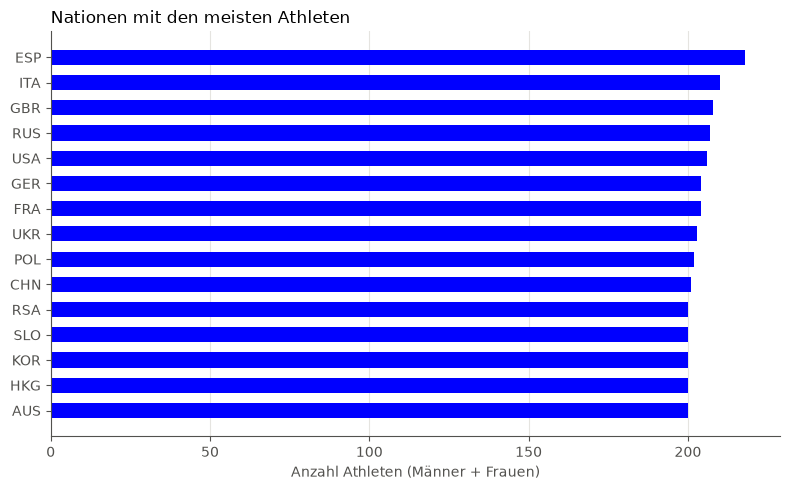

In [14]:
per_nation = ath.groupby('athlete_code').size().sort_values(ascending=False)
print(per_nation.describe().round(1))

top = per_nation.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=COLOR, height=0.6)
ax.set_xlabel('Anzahl Athleten (Männer + Frauen)')
ax.set_title('Nationen mit den meisten Athleten', loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

### 3.4 Jahrgang

Athleten ohne Jahrgang: 71
count    13091.0
mean      1995.0
std          9.4
min       1944.0
25%       1989.0
50%       1997.0
75%       2002.0
max       2012.0
Name: athlete_date, dtype: Float64


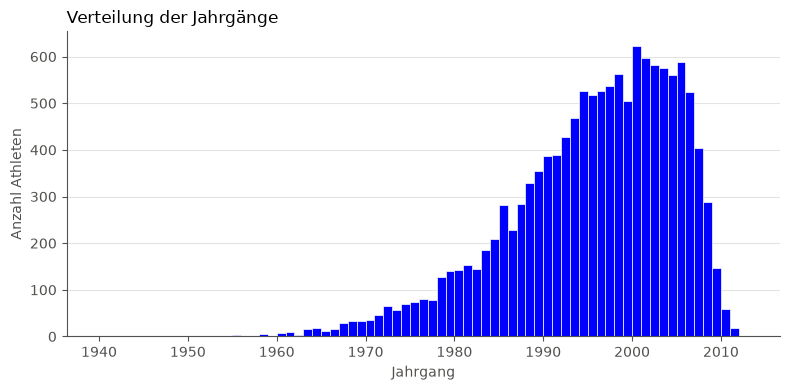

In [15]:
print(f"Athleten ohne Jahrgang: {ath['athlete_date'].isna().sum()}")
print(ath['athlete_date'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ath['athlete_date'].dropna(), bins=range(1940, 2014), color=COLOR, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Jahrgang')
ax.set_ylabel('Anzahl Athleten')
ax.set_title('Verteilung der Jahrgänge', loc='left')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### 3.5 Bestzeiten pro Athlet

count    13162.0
mean        21.7
std         14.4
min          1.0
25%          9.0
50%         19.0
75%         34.0
max        100.0
Name: n_bests, dtype: float64


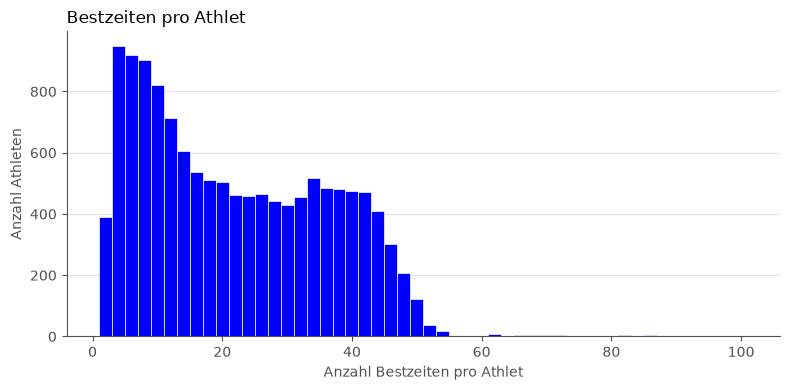

In [16]:
print(ath['n_bests'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ath['n_bests'], bins=range(1, 102, 2), color=COLOR, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Anzahl Bestzeiten pro Athlet')
ax.set_ylabel('Anzahl Athleten')
ax.set_title('Bestzeiten pro Athlet', loc='left')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### 3.6 Disziplinen und Bahnlänge

        Bestzeiten
course            
50m         148418
25m         136756


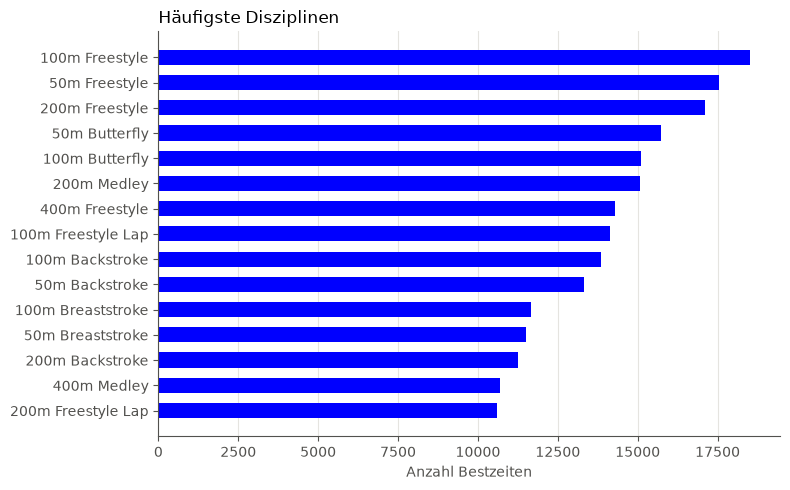

Seltenste Disziplinen:
event
150m Backstroke       4
2500m Freestyle       4
500m Breaststroke     3
1000m Breaststroke    3
150m Medley           1
20000m Freestyle      1
7500m Freestyle       1
1000m Butterfly       1
Name: count, dtype: int64


In [17]:
print(df['course'].value_counts().to_frame('Bestzeiten'))

events = df['event'].value_counts()
top = events.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=COLOR, height=0.6)
ax.set_xlabel('Anzahl Bestzeiten')
ax.set_title('Häufigste Disziplinen', loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

print('Seltenste Disziplinen:')
print(events.tail(8))

### 3.7 Wettkämpfe und Zeitraum

Bestzeiten pro Wettkampf (Median): 3 | Wettkämpfe mit nur 1 Bestzeit: 5583
                                   Bestzeiten
best_name                                    
LEN: European Short Course ...           4571
LEN: European Championships              2757
LEN: European Junior ...                 2197
World Aquatics Championships             1546
FINA: 13th World Championships           1489
New Zealand Short Course ...             1303
Mare Nostrum                             1262
Grand Prix                               1060
FINA: 13th World Short Course ...         950
Irish SC Championships                    933


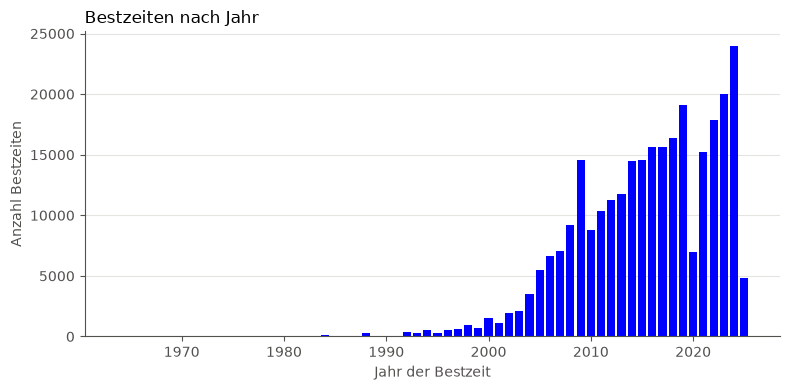

In [18]:
meets = df.loc[df['best_name'] != 'Unknown', 'best_name'].value_counts()
print(f"Bestzeiten pro Wettkampf (Median): {meets.median():.0f} | Wettkämpfe mit nur 1 Bestzeit: {(meets == 1).sum()}")
print(meets.head(10).to_frame('Bestzeiten'))

years = df['best_date'].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(years.index, years.values, color=COLOR, width=0.8)
ax.set_xlabel('Jahr der Bestzeit')
ax.set_ylabel('Anzahl Bestzeiten')
ax.set_title('Bestzeiten nach Jahr', loc='left')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### Erkenntnisse

- **Umfang:** 285'174 Bestzeiten von 13'162 Athleten aus 182 Nationen, in 55 Disziplinen und an rund 18'900 verschiedenen Wettkämpfen (1964 – 2025).
- **Geschlecht:** 55.7 % Männer, 44.3 % Frauen.
- **Nationen:** Grosse Nationen sind mit vollen Listen vertreten (rund 200 Athleten, je ~100 pro Geschlecht), die Hälfte der Nationen hat aber höchstens 28 Athleten. Die Verteilung ist stark ungleich.
- **Jahrgang:** Median 1997, die meisten Athleten sind zwischen 1989 und 2002 geboren. Bei 71 Athleten ist der Jahrgang unbekannt (NA).
- **Bestzeiten pro Athlet:** Median 19, maximal 100. Jede Disziplin wird pro Bahnlänge (25 m / 50 m) separat geführt, die beiden Bahnlängen sind etwa gleich häufig.
- **Disziplinen:** Neben den olympischen Strecken gibt es einige sehr seltene Disziplinen (z.B. 150m Medley, 20000m Freestyle) mit nur einzelnen Einträgen.
- **Zeitraum:** Die Bestzeiten stammen überwiegend aus den Jahren ab 2005. Auffällig sind der Peak 2009 (Hightech-Anzüge), der Einbruch 2020 (COVID-19) und das unvollständige Jahr 2025 (Scraping-Zeitpunkt).
- **Wettkämpfe:** Die meisten Bestzeiten stammen von internationalen Meisterschaften (LEN, World Aquatics/FINA). **Wichtig für die Netzwerkanalyse:** `best_name` ist kein eindeutiger Wettkampf-Schlüssel. Namen sind auf swimrankings.net teils abgeschnitten (z.B. `LEN: European Short Course ...`) und wiederholen sich über die Jahre. Ein Wettkampf sollte daher über die Kombination aus `best_name`, `city` und Jahr bzw. Datum identifiziert werden.